In [45]:
#IMPORTS

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA as SKPCA
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

In [46]:
#DATA IMPORT

# Load the datasets
data = pd.read_csv("sample_data_for_project_final.csv")
metadata = pd.read_csv("sample_metadata_for_project_final.csv")

metadata.columns = metadata.columns.str.strip()
y = metadata['sample_label'].values  
X = data.iloc[:, 1:].values.T

In [47]:
'''
data_full = pd.read_csv("sample_data_for_project_final.csv")
metadata_full = pd.read_csv("sample_metadata_for_project_final.csv")

metadata_full.columns = metadata_full.columns.str.strip()

# -----------------------------
# 1. Subsample variables (rows)
# -----------------------------
# Randomly pick, say, 9 variables (rows)
np.random.seed(42)  # for reproducibility
variables_to_keep = np.random.choice(data_full.index, size=9, replace=False)
data_subset = data_full.loc[variables_to_keep]

# -----------------------------
# 2. Subsample samples (columns)
# -----------------------------
# Keep only 50 samples (columns), assuming first column is variable names
sample_columns = data_subset.columns[1:]  # skip the first column which has variable names
samples_to_keep = np.random.choice(sample_columns, size=50, replace=False)
data_subset = data_subset[['Unnamed: 0'] + list(samples_to_keep)]  # keep variable name + subset

# -----------------------------
# 3. Subset metadata accordingly
# -----------------------------
metadata_subset = metadata_full[metadata_full['sample_name'].isin(samples_to_keep)]

# -----------------------------
# 4. Prepare X and y for analysis
# -----------------------------
y = metadata_subset['sample_label'].values
X = data_subset.iloc[:, 1:].values.T  # transpose so rows = samples, columns = variables
'''

'\ndata_full = pd.read_csv("sample_data_for_project_final.csv")\nmetadata_full = pd.read_csv("sample_metadata_for_project_final.csv")\n\nmetadata_full.columns = metadata_full.columns.str.strip()\n\n# -----------------------------\n# 1. Subsample variables (rows)\n# -----------------------------\n# Randomly pick, say, 9 variables (rows)\nnp.random.seed(42)  # for reproducibility\nvariables_to_keep = np.random.choice(data_full.index, size=9, replace=False)\ndata_subset = data_full.loc[variables_to_keep]\n\n# -----------------------------\n# 2. Subsample samples (columns)\n# -----------------------------\n# Keep only 50 samples (columns), assuming first column is variable names\nsample_columns = data_subset.columns[1:]  # skip the first column which has variable names\nsamples_to_keep = np.random.choice(sample_columns, size=50, replace=False)\ndata_subset = data_subset[[\'Unnamed: 0\'] + list(samples_to_keep)]  # keep variable name + subset\n\n# -----------------------------\n# 3. Subset 

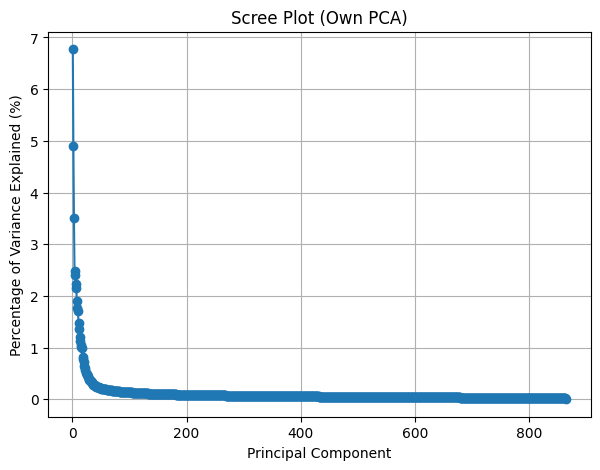

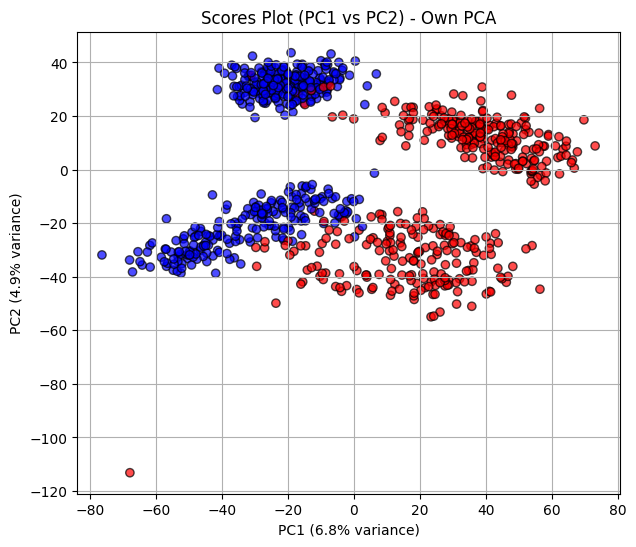

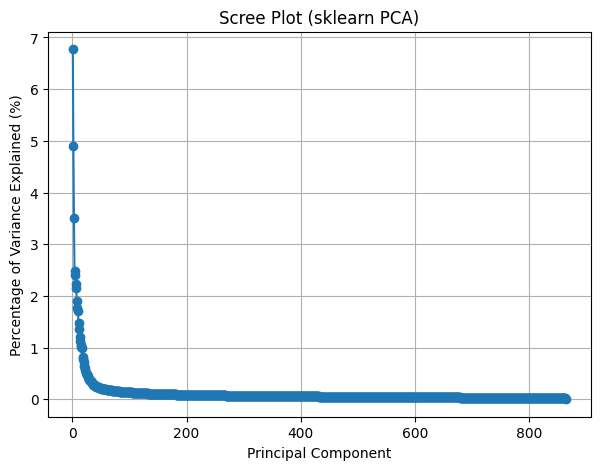

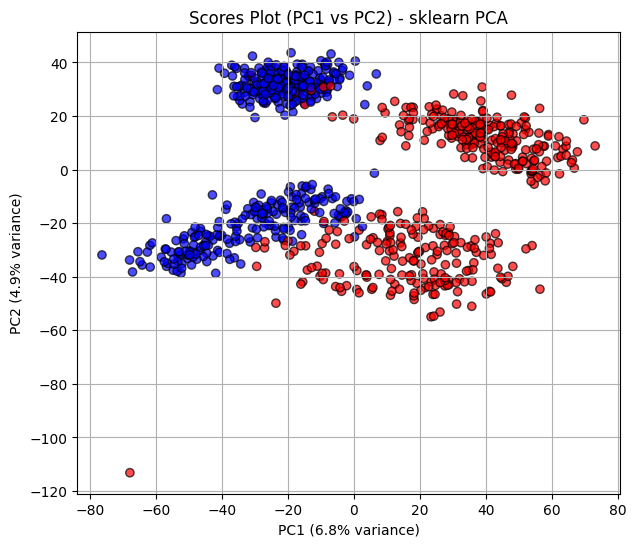

Variance explained by first 2 PCs (Own PCA): [6.77310377 4.89183609]
Variance explained by first 2 PCs (sklearn PCA): [6.77310377 4.89183609]
Own PCA: 545 components explain 90% of the variance.
Own PCA: 676 components explain 95% of the variance.
Own PCA: 816 components explain 99% of the variance.
Sklearn PCA: 545 components explain 90% of the variance.
Sklearn PCA: 676 components explain 95% of the variance.
Sklearn PCA: 816 components explain 99% of the variance.


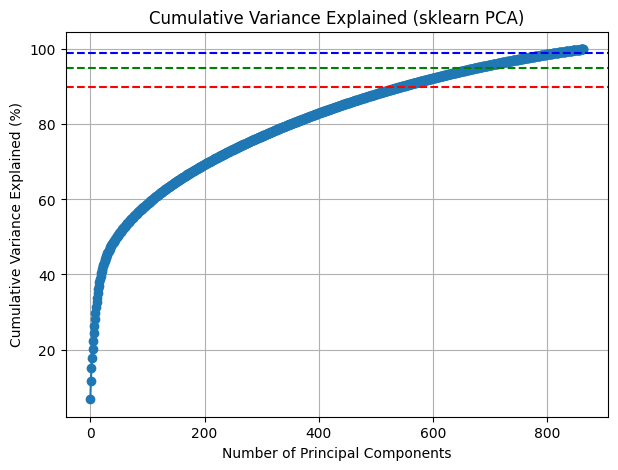

In [48]:
#PCA

# Apply PCA to the data and the samples labelled as 1 red.
class PCA:
    def __init__(self, data):
        self.data = np.array(data, dtype=float)
        self.mean_centered = None
        self.cov_matrix = None
        self.eigvals = None
        self.eigvecs = None
        self.scores = None
        self.loadings = None
        self.var_explained = None
        self.percent_var_explained = None

    def fit_PCA(self):
        # Mean-center
        self.mean_centered = self.data - np.mean(self.data, axis=0)
        # Covariance matrix
        #self.cov_matrix = np.cov(self.mean_centered, rowvar=False)
        U, S, Vt = np.linalg.svd(self.mean_centered, full_matrices=False)
        # Eigen decomposition
        #eigvals, eigvecs = np.linalg.eig(self.cov_matrix)
        #idx = np.argsort(eigvals)[::-1]
        #self.eigvals = eigvals[idx]
        #self.eigvecs = eigvecs[:, idx]
        n_samples = self.data.shape[0]
        self.eigvals = (S ** 2) / (n_samples - 1)
        self.eigvecs = Vt.T
        # Project data
        self.scores = np.dot(self.mean_centered, self.eigvecs)
        # Variance explained
        total_var = np.sum(self.eigvals)
        self.var_explained = self.eigvals
        self.percent_var_explained = (self.eigvals / total_var) * 100
        self.loadings = self.eigvecs
        return self

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca_own = PCA(X_scaled).fit_PCA()

# Scree plot
plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(pca_own.var_explained) + 1),
         pca_own.percent_var_explained, 'o-')
plt.title('Scree Plot (Own PCA)')
plt.xlabel('Principal Component')
plt.ylabel('Percentage of Variance Explained (%)')
plt.grid(True)
plt.show()

# Scores plot (PC1 vs PC2) colored by label
plt.figure(figsize=(7, 6))
plt.scatter(pca_own.scores[:, 0], pca_own.scores[:, 1],
            c=np.where(y==0, 'blue', 'red'), edgecolor='k', alpha=0.7)
plt.title('Scores Plot (PC1 vs PC2) - Own PCA')
plt.xlabel(f'PC1 ({pca_own.percent_var_explained[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_own.percent_var_explained[1]:.1f}% variance)')
plt.grid(True)
plt.show()


# Apply PCA to the data using PCA in sklearn. Plot the scree plot and scores plot

pca_skl = SKPCA()
pca_skl.fit(X_scaled)
scores_skl = pca_skl.transform(X_scaled)

# Scree plot
plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(pca_skl.explained_variance_ratio_)+1),
         pca_skl.explained_variance_ratio_*100, 'o-')
plt.title('Scree Plot (sklearn PCA)')
plt.xlabel('Principal Component')
plt.ylabel('Percentage of Variance Explained (%)')
plt.grid(True)
plt.show()

# Scores plot (PC1 vs PC2) colored by label
plt.figure(figsize=(7, 6))
plt.scatter(scores_skl[:, 0], scores_skl[:, 1],
            c=np.where(y==0, 'blue', 'red'), edgecolor='k', alpha=0.7)
plt.title('Scores Plot (PC1 vs PC2) - sklearn PCA')
plt.xlabel(f'PC1 ({pca_skl.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_skl.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True)
plt.show()

#Compare the scree plot and scores plot you have obtained from the two methods. How similar are the two plots?
print(f"Variance explained by first 2 PCs (Own PCA): {pca_own.percent_var_explained[:2]}")
print(f"Variance explained by first 2 PCs (sklearn PCA): {pca_skl.explained_variance_ratio_[:2]*100}")

# Cumulative variaces 
# Cumulative variance explained (own PCA)
cum_var_own = np.cumsum(pca_own.percent_var_explained)
# Print how many PCs reach 90%, 95%, 99%
for threshold in [90, 95, 99]:
    num_components = np.argmax(cum_var_own >= threshold) + 1
    print(f"Own PCA: {num_components} components explain {threshold}% of the variance.")
# Cumulative variance explained (sklearn PCA)
cum_var_skl = np.cumsum(pca_skl.explained_variance_ratio_ * 100)
for threshold in [90, 95, 99]:
    num_components = np.argmax(cum_var_skl >= threshold) + 1
    print(f"Sklearn PCA: {num_components} components explain {threshold}% of the variance.")
#Plot
plt.figure(figsize=(7,5))
plt.plot(cum_var_skl, marker='o')
plt.axhline(90, color='r', linestyle='--')
plt.axhline(95, color='g', linestyle='--')
plt.axhline(99, color='b', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained (%)")
plt.title("Cumulative Variance Explained (sklearn PCA)")
plt.grid(True)
plt.show()

Number of pairs with |r| > 0.997: 33


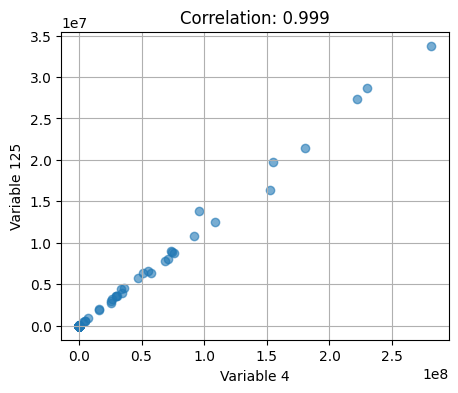

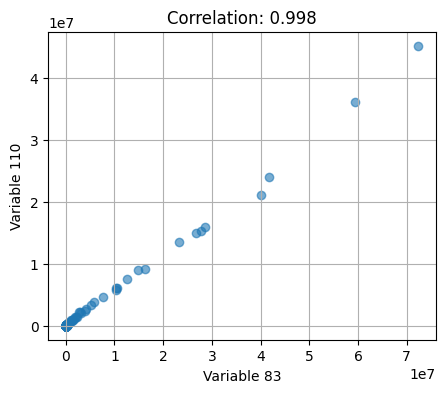

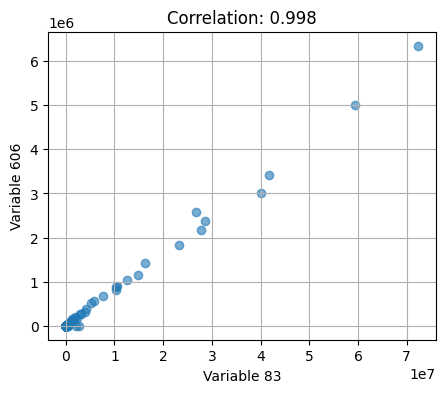

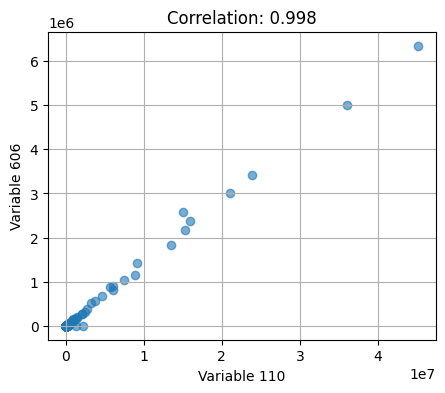

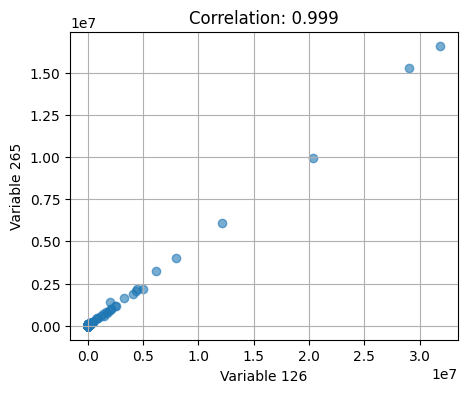

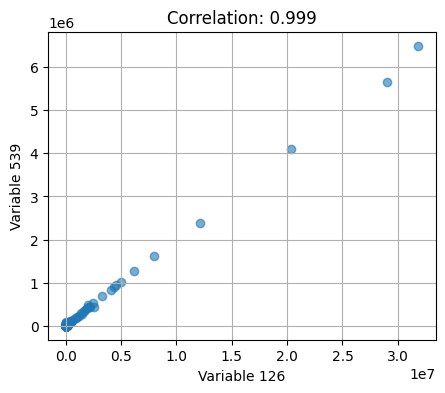

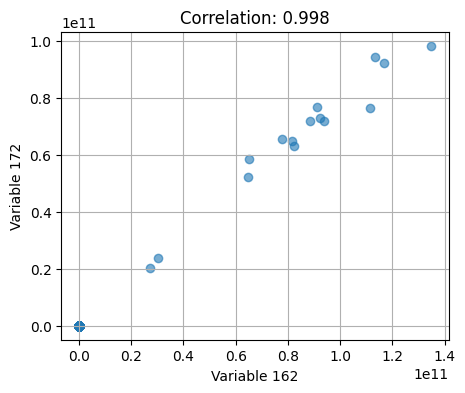

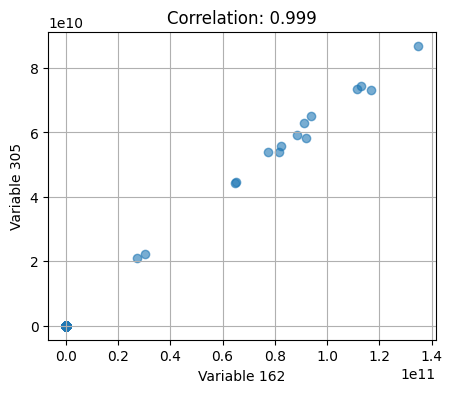

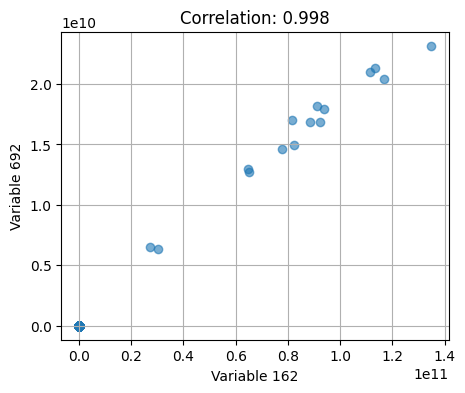

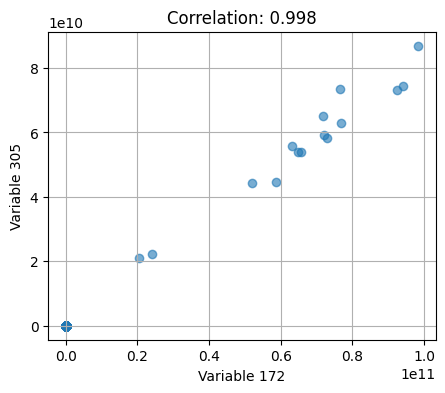

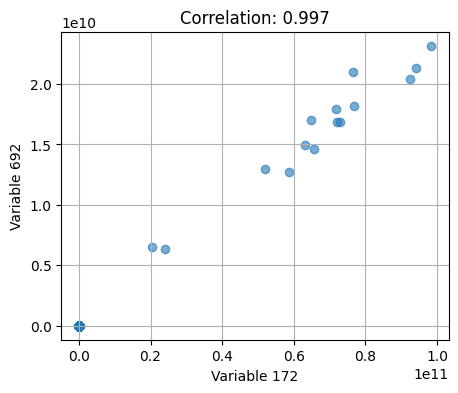

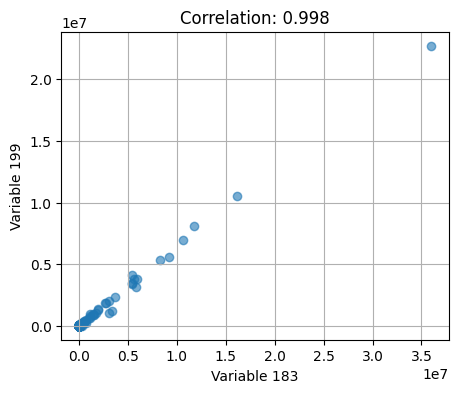

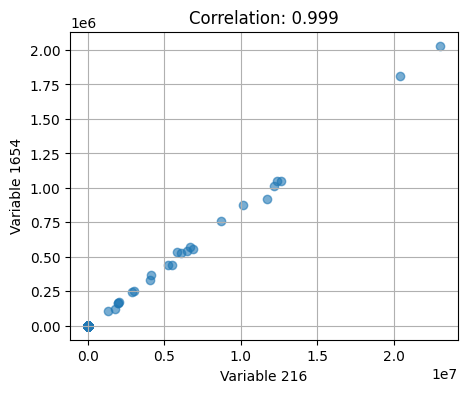

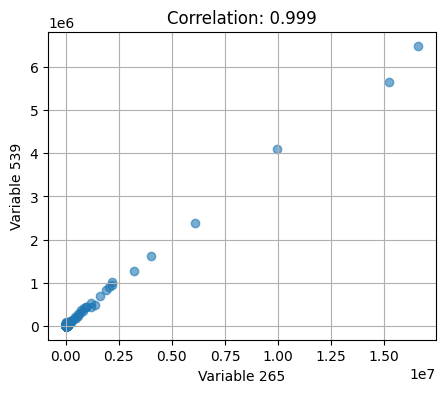

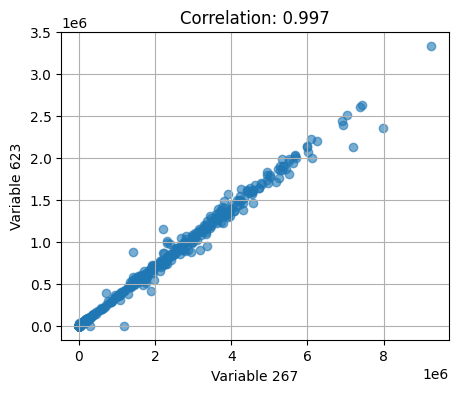

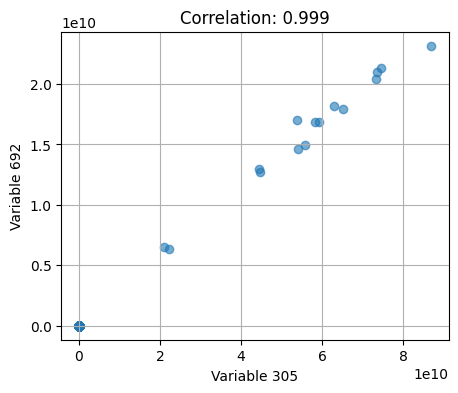

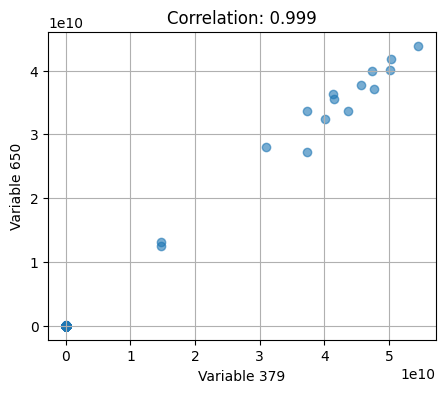

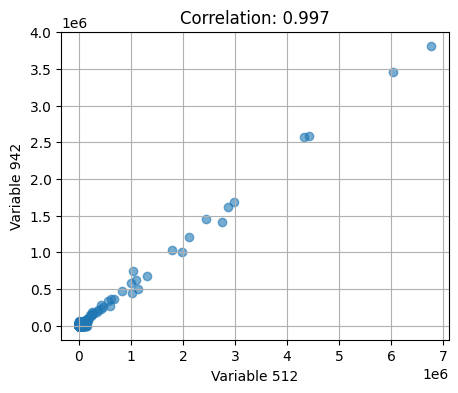

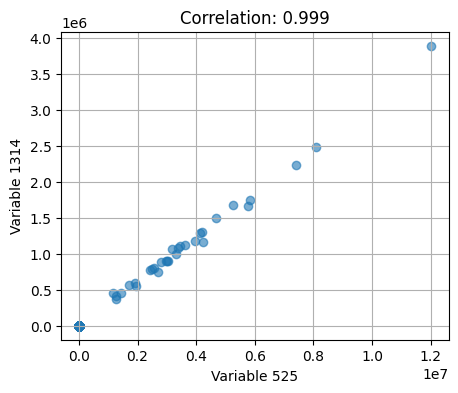

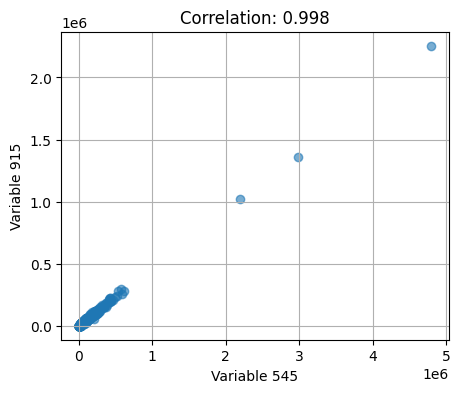

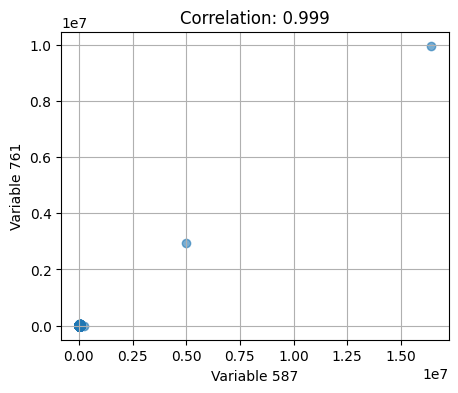

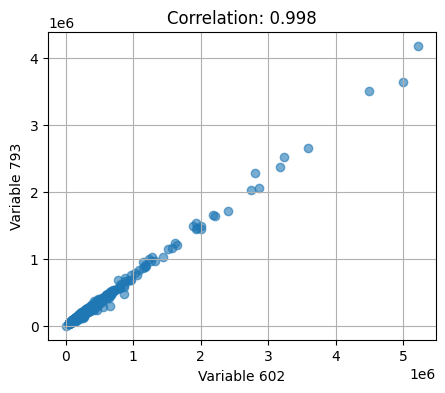

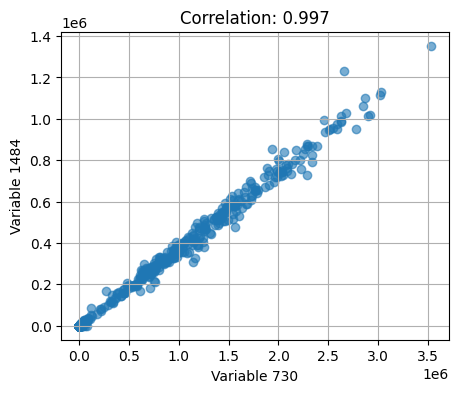

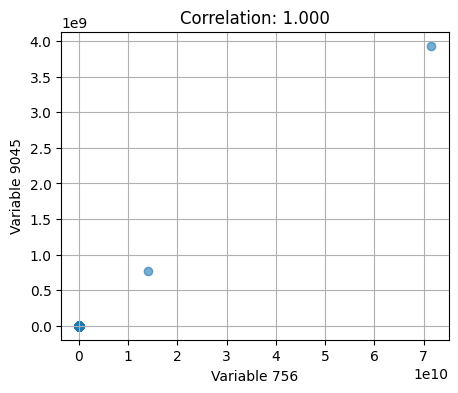

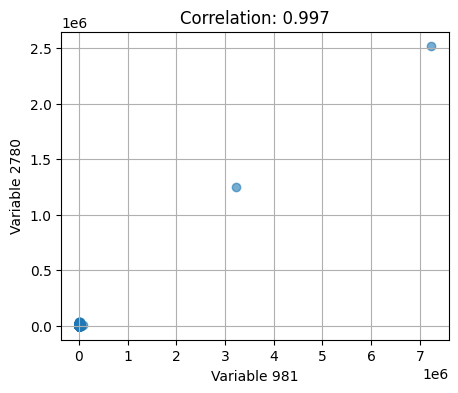

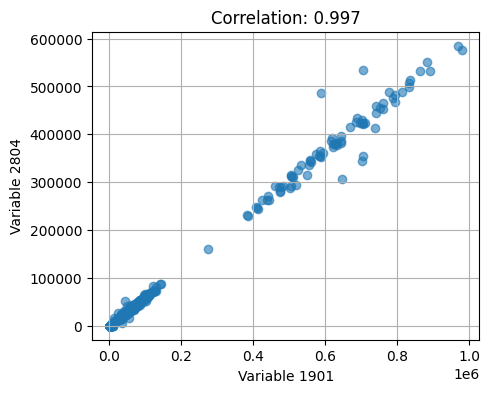

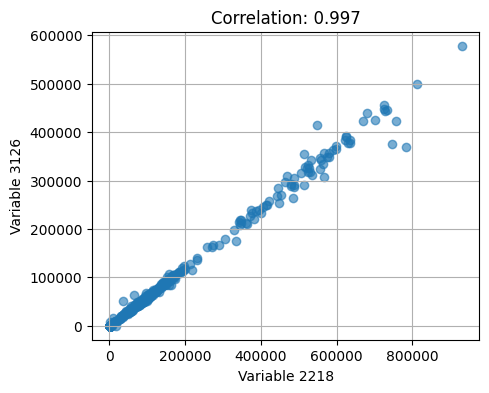

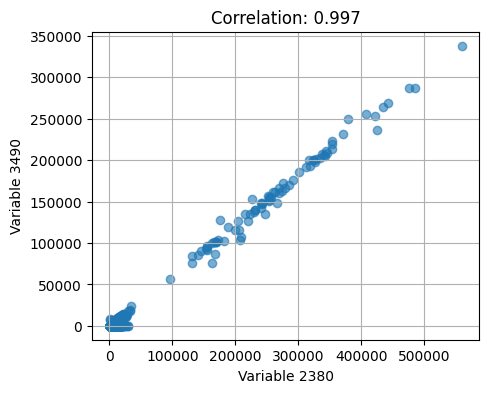

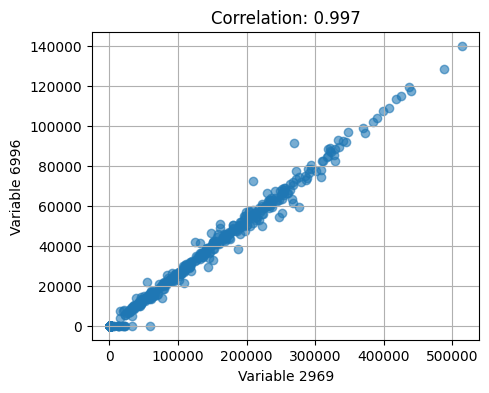

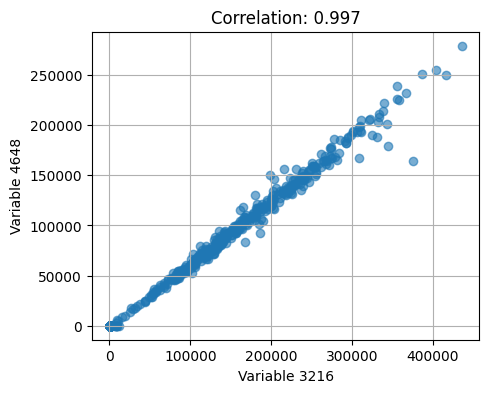

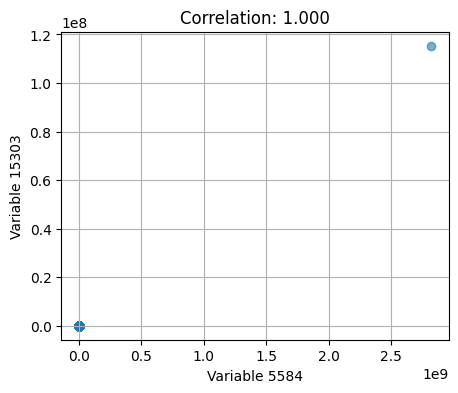

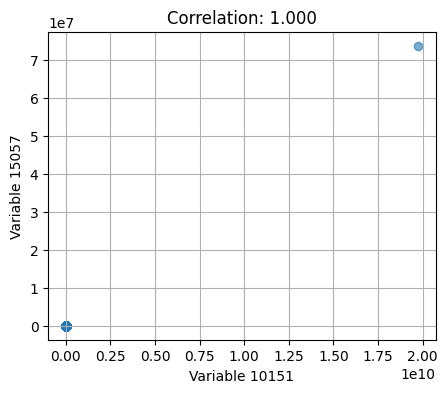

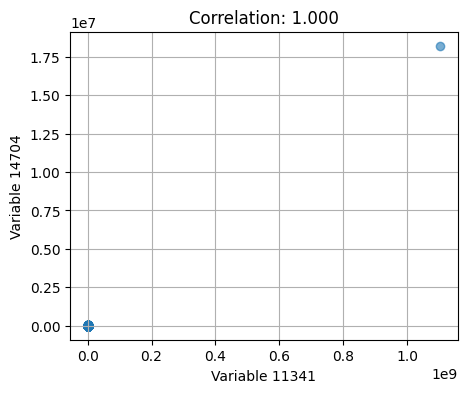

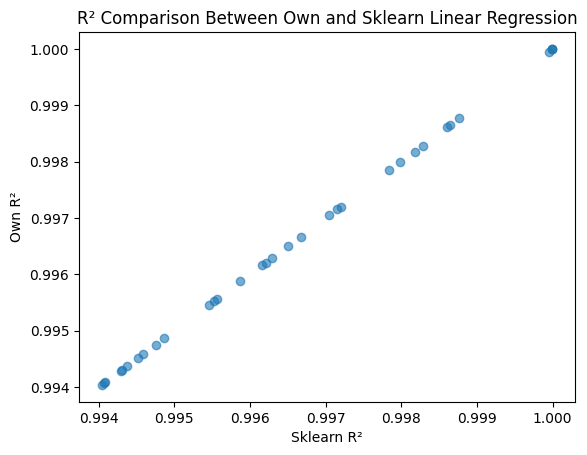

Correlation between R² values: 1.000


In [49]:
#LINEAR REGRESSION

#Apply your own linear regression scripts to the data. 
class LRAnalytical:

    def __init__(self):
        self.intercept = 0.0
        self.slope = 0.0
    
    # Fit linear regression for one predictor
    def fit_LR(self, X, Y):
        X = np.array(X)
        Y = np.array(Y)
        
        # Add column of 1s for intercept
        X_design = np.c_[np.ones(X.shape[0]), X]

        # Closed-form solution
        theta = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ Y)

        self.intercept, self.slope = theta[0], theta[1]
        return self

    # Predict values
    def predictions(self, X):
        X = np.array(X)
        return self.intercept + self.slope * X

    # Return slope and intercept
    def get_params(self):
        return self.intercept, self.slope

    # Compute R²
    def r2_score(self, X, Y):
        Y = np.array(Y)
        Y_pred = self.predictions(X)
        ss_res = np.sum((Y - Y_pred)**2)
        ss_tot = np.sum((Y - np.mean(Y))**2)
        return 1 - (ss_res / ss_tot)
    
# Standardize features
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

#Find all pairs of variables that are linearly correlated with correlation coefficient greater than 0.997
corr_matrix = np.corrcoef(X_std.T)  
threshold = 0.997

# Get pairs where |r| > 0.997
pairs = np.argwhere(np.triu(np.abs(corr_matrix), k=1) > threshold)
print(f"Number of pairs with |r| > {threshold}: {len(pairs)}")

#Make a scatter plot of all of these pairs and annotate each plot with the value of the correlation coefficient.
for i, j in pairs:
    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, i], X[:, j], alpha=0.6)
    plt.xlabel(f"Variable {i}")
    plt.ylabel(f"Variable {j}")
    plt.title(f"Correlation: {corr_matrix[i,j]:.3f}")
    plt.grid(True)
    plt.show()

#Apply linear regression to the data using linear regression in sklearn and get the R2 values.
own_r2 = []
sklearn_r2 = []

for i, j in pairs:
    # Own implementation
    model = LRAnalytical()
    model.fit_LR(X[:, i], X[:, j])
    own_r2.append(model.r2_score(X[:, i], X[:, j]))
    
    # Sklearn implementation
    lr = LinearRegression().fit(X[:, i].reshape(-1,1), X[:, j])
    sklearn_r2.append(lr.score(X[:, i].reshape(-1,1), X[:, j]))

own_r2 = np.array(own_r2)
sklearn_r2 = np.array(sklearn_r2)

# Filter R^2 > 0.8
mask = own_r2 > 0.8

#Make a scatter plot of all of the R2 values greater than 0.8, if there are more than 5 of these R2
#values calculated by your own scripts. Compute the R2 value of the relationship between the R2 values from your own scripts
#and the R2 value from sklearn.
if len(own_r2) > 5:
    plt.scatter(sklearn_r2, own_r2, alpha=0.6)
    plt.xlabel("Sklearn R²")
    plt.ylabel("Own R²")
    plt.title("R² Comparison Between Own and Sklearn Linear Regression")
    plt.show()
    
    corr_r2 = np.corrcoef(own_r2, sklearn_r2)[0,1]
    print(f"Correlation between R² values: {corr_r2:.3f}")

Number of pairs with |r| > 0.997: 33


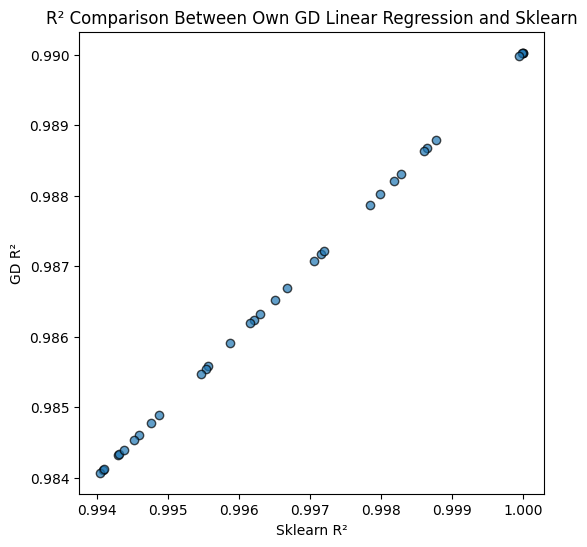

Correlation between R² values (R²>0.8): 1.000


In [50]:
#LINEAR REGRESSION CONTINUED

# LINEAR REGRESSION - Gradient Descent
class LRGradient:
    def __init__(self, learning_rate=0.001, tolerance=1e-5, max_iterations=100000):
        self.intercept = 0.0
        self.slope = 0.0
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iterations = max_iterations
        self.cost_history = []

    def compute_cost(self, X, Y):
        m = len(Y)
        predictions = self.intercept + self.slope * X
        cost = (1/(2*m)) * np.sum((predictions - Y) ** 2)
        return cost

    def fit_GR(self, X, Y):
        X = np.array(X)
        Y = np.array(Y)
        m = len(Y)
        self.intercept, self.slope = 0.0, 0.0
        prev_cost = float("inf")

        for iteration in range(self.max_iterations):
            predictions = self.intercept + self.slope * X
            d_intercept = (1/m) * np.sum(predictions - Y)
            d_slope = (1/m) * np.sum((predictions - Y) * X)

            self.intercept -= self.learning_rate * d_intercept
            self.slope -= self.learning_rate * d_slope

            current_cost = self.compute_cost(X, Y)
            self.cost_history.append(current_cost)

            if abs(prev_cost - current_cost) < self.tolerance:
                break
            prev_cost = current_cost

        return self

    def predictions(self, X):
        return self.intercept + self.slope * X

    def r2_score(self, X, Y):
        Y_pred = self.predictions(X)
        ss_res = np.sum((Y - Y_pred)**2)
        ss_tot = np.sum((Y - np.mean(Y))**2)
        return 1 - (ss_res / ss_tot)

# Standardize Data
# X should be your data matrix (samples x variables)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)


# Find highly correlated variable pairs

corr_matrix = np.corrcoef(X_std.T)
threshold = 0.997

pairs = np.argwhere(np.triu(np.abs(corr_matrix), k=1) > threshold)
print(f"Number of pairs with |r| > {threshold}: {len(pairs)}")


# Compute R² for all pairs using GD and sklearn

own_r2 = []
sklearn_r2 = []

for i, j in pairs:
    # Gradient Descent
    model = LRGradient(learning_rate=0.001, tolerance=1e-5, max_iterations=100000)
    model.fit_GR(X_std[:, i], X_std[:, j])
    own_r2_val = model.r2_score(X_std[:, i], X_std[:, j])
    own_r2.append(own_r2_val)

    # Sklearn
    lr = LinearRegression().fit(X_std[:, i].reshape(-1,1), X_std[:, j])
    sklearn_r2_val = lr.score(X_std[:, i].reshape(-1,1), X_std[:, j])
    sklearn_r2.append(sklearn_r2_val)

own_r2 = np.array(own_r2)
sklearn_r2 = np.array(sklearn_r2)

# Plot R² comparison for values > 0.8

mask = own_r2 > 0.8
if np.sum(mask) > 5:
    plt.figure(figsize=(6,6))
    plt.scatter(sklearn_r2[mask], own_r2[mask], alpha=0.7, edgecolor='k')
    plt.xlabel("Sklearn R²")
    plt.ylabel("GD R²")
    plt.title("R² Comparison Between Own GD Linear Regression and Sklearn")
    plt.grid(False)
    plt.show()

    # Correlation between R² values
    corr_r2 = np.corrcoef(own_r2[mask], sklearn_r2[mask])[0,1]
    print(f"Correlation between R² values (R²>0.8): {corr_r2:.3f}")

Converged after 1714 iterations

Accuracy (Own Logistic Regression): 0.988
Accuracy (Sklearn Logistic Regression): 1.000


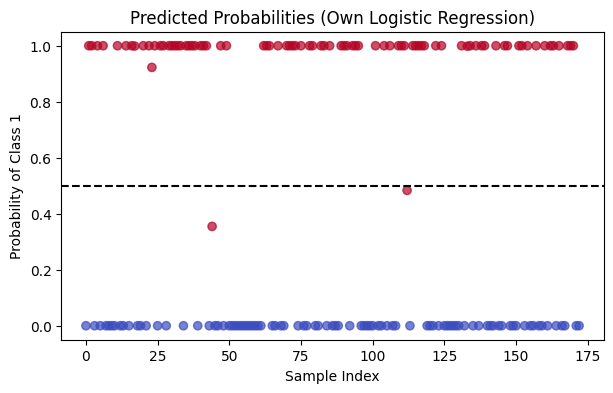

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# STANDARDIZE + TRAIN-TEST SPLIT
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# OWN LOGISTIC REGRESSION (GRADIENT DESCENT)

class LogisticRegressionGD:
    def __init__(self, learning_rate=0.1, tolerance=1e-6, max_iterations=20000):
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iterations = max_iterations
        self.theta = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit_GR(self, X, y):
        X = np.hstack([np.ones((X.shape[0], 1)), X])  # Add bias term
        y = y.reshape(-1, 1)
        m, n = X.shape

        self.theta = np.zeros((n, 1))

        for i in range(self.max_iterations):
            h = self.sigmoid(X @ self.theta)
            gradient = (1/m) * (X.T @ (h - y))

            # Gradient descent update
            update = self.learning_rate * gradient
            self.theta -= update

            if np.max(np.abs(update)) < self.tolerance:
                print(f"Converged after {i+1} iterations")
                break

        return self

    def predict_proba(self, X):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        return self.sigmoid(X @ self.theta)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int).flatten()

# TRAIN OWN LOGISTIC MODEL
own_model = LogisticRegressionGD(
    learning_rate=0.1,
    tolerance=1e-6,
    max_iterations=20000
)

own_model.fit_GR(X_train, y_train)
y_pred_own = own_model.predict(X_test)

accuracy_own = accuracy_score(y_test, y_pred_own)
print(f"\nAccuracy (Own Logistic Regression): {accuracy_own:.3f}")

# SKLEARN LOGISTIC REGRESSION

sk_model = LogisticRegression(
    C=1.0,                
    solver='lbfgs',
    max_iter=10000
)

sk_model.fit(X_train, y_train)
y_pred_sklearn = sk_model.predict(X_test)

accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Accuracy (Sklearn Logistic Regression): {accuracy_sklearn:.3f}")

# PROBABILITY PLOT (fixed indexing)
y_prob_own = own_model.predict_proba(X_test).flatten()

plt.figure(figsize=(7,4))
plt.scatter(range(len(y_test)), y_prob_own, c=y_test, cmap="coolwarm", alpha=0.7)
plt.axhline(0.5, color="black", linestyle="--")
plt.title("Predicted Probabilities (Own Logistic Regression)")
plt.xlabel("Sample Index")
plt.ylabel("Probability of Class 1")
plt.show()


Iteration 0: Cost=0.7219
Iteration 100: Cost=0.0153
Iteration 200: Cost=0.0064
Iteration 300: Cost=0.0043
Iteration 400: Cost=0.0031
Custom ANN Accuracy: 0.9827


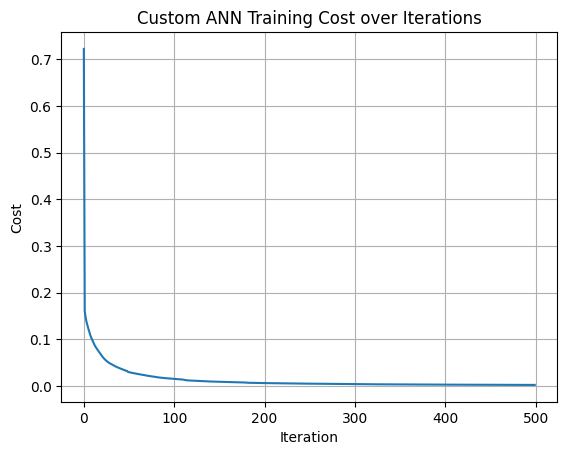

Sklearn ANN Accuracy: 0.9942


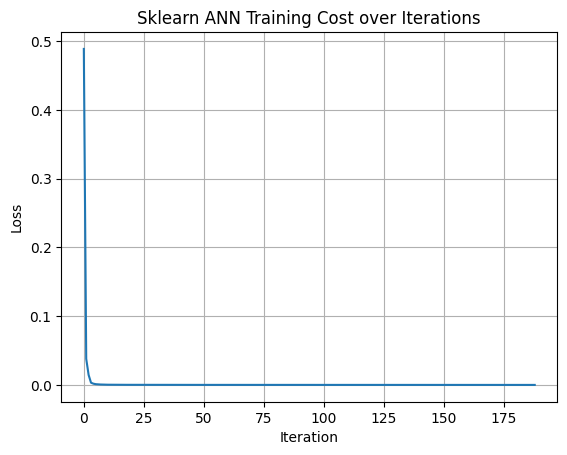

In [52]:
#ARTIFICIAL NEURAL NETWORK(ANN)

#Use the training and testing dataset that you have obtained when doing logistic regression.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Build an ANN model using your own scripts 
class CustomANN:
    def __init__(self, n_inputs, n_hidden, n_output, learning_rate=0.05, num_iterations=1000):
        self.n_inputs = n_inputs
        self.n_hidden = n_hidden
        self.n_output = n_output
        self.lr = learning_rate
        self.num_iterations = num_iterations
        
        # Xavier initialization
        self.W1 = np.random.randn(n_hidden, n_inputs) * np.sqrt(1 / n_inputs)
        self.b1 = np.zeros((n_hidden, 1))
        self.W2 = np.random.randn(n_output, n_hidden) * np.sqrt(1 / n_hidden)
        self.b2 = np.zeros((n_output, 1))
        
        self.cost_list = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def forward(self, X):
        Z1 = self.W1 @ X + self.b1
        A1 = np.tanh(Z1)
        Z2 = self.W2 @ A1 + self.b2
        A2 = self.sigmoid(Z2)
        cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
        return A2, cache
    
    def compute_cost(self, A2, Y):
        m = Y.shape[1]
        cost = -np.sum(Y*np.log(A2 + 1e-8) + (1-Y)*np.log(1-A2 + 1e-8)) / m
        return cost
    
    def backward(self, X, Y, cache):
        m = X.shape[1]
        A1 = cache['A1']
        A2 = cache['A2']
        
        dZ2 = A2 - Y
        dW2 = (1/m) * dZ2 @ A1.T
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
        
        dA1 = self.W2.T @ dZ2
        dZ1 = dA1 * (1 - A1**2)
        dW1 = (1/m) * dZ1 @ X.T
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
        
        # Update weights
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
    
    def fit(self, X, Y):
        X = X.T
        Y = Y.reshape(1, -1)
        for i in range(self.num_iterations):
            A2, cache = self.forward(X)
            cost = self.compute_cost(A2, Y)
            self.cost_list.append(cost)
            self.backward(X, Y, cache)
            if i % 100 == 0:
                print(f"Iteration {i}: Cost={cost:.4f}")
    
    def predict(self, X):
        X = X.T
        A2, _ = self.forward(X)
        return (A2 > 0.5).astype(int).flatten()
    
#Testing your model on the testing dataset. What is your accuracy?
ann = CustomANN(n_inputs=X_train.shape[1], n_hidden=10, n_output=1, learning_rate=0.1, num_iterations=500)
ann.fit(X_train, y_train)

y_pred_custom = ann.predict(X_test)
acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"Custom ANN Accuracy: {acc_custom:.4f}")

# Plot cost
plt.figure()
plt.plot(ann.cost_list)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Custom ANN Training Cost over Iterations')
plt.grid(True)
plt.show()

#Build an ANN model using sklearn and the ANN architecture that your own ANN scripts used
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),   
    activation='relu',          
    solver='adam',              
    learning_rate_init=0.0005,  
    max_iter=5000,              
    tol=1e-7,                   
    random_state=42
)
mlp.fit(X_train, y_train)

#Testing your model on the testing dataset. What is sklearn’s accuracy?
y_pred_sklearn = mlp.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Sklearn ANN Accuracy: {acc_sklearn:.4f}")

# Plot sklearn ANN loss curve
plt.figure()
plt.plot(mlp.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Sklearn ANN Training Cost over Iterations')
plt.grid(True)
plt.show()

In [55]:
#Describe your results

'''
PCA

In my own implementation of PCA, the scree plot showed that PC1 explains about 6.8% of the total variance and PC2 explains about 4.9%. The scores plot revealed 
four partially separated clusters, consisting of two blue clusters (class 0) and two red clusters (class 1). PC2 provided the strongest separation between the two
main classes, while PC1 helped distinguish two smaller sub-clusters. Some overlap between the clusters was still present, indicating that although the dataset contains 
distinguishable class structure, the classes are not perfectly separable in the first two principal components. My sklearn PCA results were essentially identical. 
The explained variance for each component, as well as the overall structure of both the scree plot and scores plot, matched my own PCA implementation. This confirms that my 
PCA algorithm (based on SVD and manual variance computation) is working correctly. Both methods also showed that approximately 816 principal components are required to explain 
99% of the variance in the dataset.

LINEAR REGRESSION

Using my analytical linear regression implementation, I identified 33 pairs of variables with correlation coefficients greater than 0.997. For each of these pairs, I generated 
scatter plots and annotated each plot with its corresponding correlation coefficient. As expected, all pairs displayed nearly perfect linear relationships due to the very high 
correlation threshold.I computed R2 values using both my implementation and sklearn’s LinearRegression. Across all highly correlated pairs, the 
R2 values from my implementation and sklearn were identical up to numerical precision, with a correlation of 1.000 between the two sets of results. This confirms that both my 
closed-form analytical solution and my gradient-descent linear regression produced consistent, correct values.

LOGISTIC REGRESSION

Using an 80/20 train-test split (stratified to maintain label proportions), I trained my own logistic regression model implemented with gradient descent. My model converged 
after 1,714 iterations and achieved a test accuracy of 0.988. The sklearn logistic regression model achieved a slightly higher accuracy of 1.000 on the same test set. This
difference is expected because sklearn uses the LBFGS optimizer, which generally converges faster and more reliably than basic gradient descent, and it also handles 
regularization and numerical stability automatically. The predicted-probability plot from my implementation shows a clear separation between the classes with respect to the
0.5 threshold, with only a few misclassified red points falling below the line. This visually matches the small drop in accuracy compared to sklearn.

ANN

Using the same training and testing sets from the logistic regression task, I implemented and trained a custom ANN consisting of:1 hidden layer with 10 neurons, Tanh activation 
in the hidden layer, Sigmoid activation in the output layer, Xavier initialization for all weights, and gradient descent updates. My custom ANN achieved a test accuracy of 0.9884.
The cost curve showed a steep drop during the early iterations, with a slower, steady decline afterward, confirming that the network learned appropriately.I then trained an ANN 
using sklearn’s MLPClassifier with an architecture comparable to my implementation. The sklearn model achieved a slightly higher accuracy of 0.9942. The training curve for the 
sklearn ANN was smoother, with a well-defined elbow around a lower cost value, which is expected because it uses the Adam optimizer, adaptive learning rates, and regularization.
'''